# 🔬 Cancer Image Classification — VGG19-BN

Transfer-learning pipeline built on **VGG19 with Batch Normalisation** (pretrained on ImageNet)  
to classify breast-ultrasound scans from the **BUSI dataset** into three categories:  
`benign` · `malignant` · `normal`

---
**Pipeline overview**
1. Import libraries
2. Define constants & transforms
3. Load dataset & visualise random samples
4. Filter mask images & split into train / test (augmentation on train only)
5. Build DataLoaders
6. Visualise batches
7. Define model (VGG19-BN fine-tuning) + class weights
8. Training loop with weighted loss & early stopping
9. Plot learning curves
10. Evaluate predictions on test set (confusion matrix + classification report)


## 1 · Import Libraries


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ── PyTorch core ──────────────────────────────────────────────────────────────
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch import max, no_grad, manual_seed, save,tensor,device,is_tensor

# ── TorchVision ───────────────────────────────────────────────────────────────
import torchvision.transforms as transforms
from torchvision.models import vgg19_bn                    # VGG19 + Batch Norm
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

# ── Data utilities ────────────────────────────────────────────────────────────
from torch.utils.data import random_split, Subset
from torch.utils.data.dataloader import DataLoader

from tqdm import tqdm                                       # progress bars for training loop
from collections import Counter
import pandas as pd

# ── Evaluation ────────────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


## 2 · Constants & Transforms


In [ ]:
# ── Dataset path ──────────────────────────────────────────────────────────────
PATH = r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\Cancer Images Dataset\Dataset_BUSI_with_GT"

# ── Image settings ────────────────────────────────────────────────────────────
IMG_SIZE     = (224, 224)  # VGG19 expects 224×224 input
PERMUTE_SIZE = (1, 2, 0)   # CHW → HWC for matplotlib

# ── Split ratio ───────────────────────────────────────────────────────────────
SPLIT_SIZES = [0.8, 0.2]   # 80 % train · 20 % test

# ── Model settings ────────────────────────────────────────────────────────────
NUM_OF_CLASSES = 3           # benign · malignant · normal
PATIENCE       = 5           # early-stopping patience (epochs without improvement)
BEST_VAL_LOSS  = float('inf')  # initialise best loss tracker

# ── Training settings ─────────────────────────────────────────────────────────
BATCH_SIZE = 12
EPOCHS     = 50
LR         = 1e-5            # low LR for fine-tuning a pretrained model

# ── Transforms ────────────────────────────────────────────────────────────────
# Train: augmentation helps the model generalise to unseen scans
TRAIN_TRANSFORMS = transforms.Compose([
    transforms.Resize(IMG_SIZE),                    # match VGG19 input size
    transforms.ColorJitter(brightness=0.2),         # slight brightness variation
    transforms.GaussianBlur(kernel_size=(3, 3)),    # smooth noise for robustness
    transforms.RandomHorizontalFlip(),              # mirror scan (clinically valid)
    transforms.ToTensor(),                          # PIL → FloatTensor [0, 1]

    
])

# Test: no augmentation — evaluate on clean, unmodified images
TEST_TRANSFORMS = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

# Quick sanity-check — list top-level class folders
os.listdir(PATH)


['benign', 'malignant', 'normal']

## 3 · Load Dataset & Visualise Random Samples


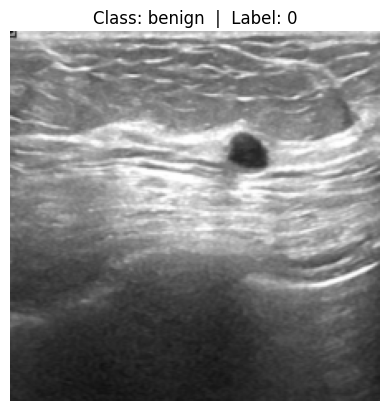

In [ ]:
# Load the full dataset with TEST transforms (no augmentation) for exploration only
dataset = ImageFolder(PATH, TEST_TRANSFORMS)

def Show_Random_Image(dataset):
    """Pick a random sample from *dataset* and display it with its class label."""
    idx        = np.random.randint(len(dataset))
    img, label = dataset[idx]

    # .classes lives on ImageFolder; Subset wraps it one level deeper
    try:
        class_name = dataset.classes[label]
    except AttributeError:
        class_name = dataset.dataset.classes[label]

    plt.imshow(img.permute(PERMUTE_SIZE))
    plt.title(f"Class: {class_name}  |  Label: {label}")
    plt.axis("off")
    plt.show()

Show_Random_Image(dataset)


In [ ]:
print(pd.Series(dataset.targets).value_counts())

0    891
1    421
2    266
Name: count, dtype: int64


## 4 · Filter Mask Images & Split into Train / Test

The BUSI dataset ships each ultrasound scan paired with a `_mask` PNG (segmentation ground truth).  
We keep **only the original scans** — paths that do **not** contain the word `mask`.

> **Why two `ImageFolder` calls?**  
> `ImageFolder` stores a single transform for the whole dataset.  
> Loading the same folder twice — each with its own `Compose` — and slicing  
> disjoint indices via `Subset` is the cleanest way to guarantee augmentation  
> is applied **only** to the training split, never to the test split.


In [ ]:
# ── Step 1: load without transforms to collect sample paths ───────────────────
base_dataset = ImageFolder(PATH)

# Keep indices whose file path does NOT contain 'mask'
dataset_valid_indices = [
    i for i, (path, _) in enumerate(base_dataset.samples)
    if "mask" not in path
]

# Shuffle before splitting to ensure class balance across train & test
np.random.shuffle(dataset_valid_indices)

# ── Step 2: 80 / 20 index split ───────────────────────────────────────────────
train_size    = int(SPLIT_SIZES[0] * len(dataset_valid_indices))
train_indices = dataset_valid_indices[:train_size]
test_indices  = dataset_valid_indices[train_size:]

# ── Step 3: two ImageFolder objects with DIFFERENT transforms ─────────────────
# train_ds → augmentation ON  |  test_ds → augmentation OFF
train_ds = Subset(ImageFolder(PATH, TRAIN_TRANSFORMS), train_indices)
test_ds  = Subset(ImageFolder(PATH, TEST_TRANSFORMS),  test_indices)

print(f"Total valid samples : {len(dataset_valid_indices)}")
print(f"Train samples       : {len(train_ds)}")
print(f"Test  samples       : {len(test_ds)}")


Total valid samples : 780
Train samples       : 624
Test  samples       : 156


In [ ]:
# ── Sanity check: confirm each split has the correct transform pipeline ────────
print("Train transform:\n", train_ds.dataset.transform)
print()
print("Test  transform:\n",  test_ds.dataset.transform)


Train transform:
 Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ColorJitter(brightness=(0.8, 1.2), contrast=None, saturation=None, hue=None)
    GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0))
    RandomHorizontalFlip(p=0.5)
    ToTensor()
)

Test  transform:
 Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [ ]:
classes_counts = []
for ds in [train_ds,test_ds]:
    label_list   = [label for _, label in ds]
    class_counts = [Counter(label_list)[i] for i in range(NUM_OF_CLASSES)]
    classes_counts.append(class_counts)


print(f"Train_DS Class counts:", classes_counts[0])
print(f"Test_DS Class counts:", classes_counts[1])

Train_DS Class counts: 92
Test_DS Class counts: 44


## 5 · Build DataLoaders


In [ ]:
# shuffle=True  on train → breaks class-ordering bias every epoch
# shuffle=False on test  → reproducible evaluation order
train_dl = DataLoader(dataset=train_ds, batch_size=BATCH_SIZE, shuffle=True)
# val_dl = DataLoader(dataset=val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl  = DataLoader(dataset=test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_dl)}")
print(f"Test  batches : {len(test_dl)}")


Train batches : 52
Test  batches : 13


## 6 · Visualise Image Batches


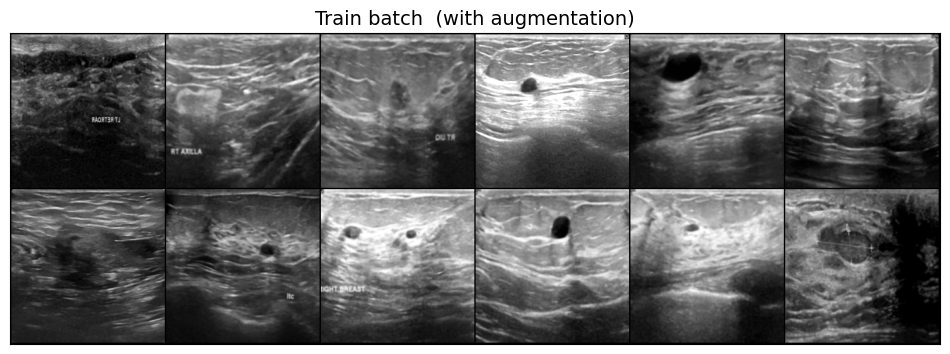

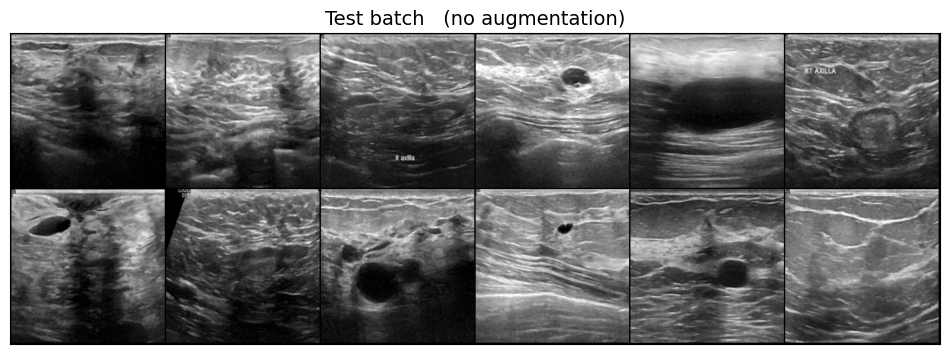

In [ ]:
def Show_Grid_Of_Images(dl, title=""):
    """Display the first batch from *dl* as an image grid (5 images per row)."""
    _, ax = plt.subplots(figsize=(12, 10))
    imgs, _ = next(iter(dl))
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_title(title, fontsize=14)
    ax.imshow(make_grid(imgs, nrow=6).permute(PERMUTE_SIZE))
    plt.show()

# Train batch — images should look varied due to augmentation
Show_Grid_Of_Images(train_dl, title="Train batch  (with augmentation)")

# Test batch — images should look clean with no augmentation
Show_Grid_Of_Images(test_dl,  title="Test batch   (no augmentation)")


## 7 · Model Definition — VGG19-BN Fine-Tuning

We load **VGG19 with Batch Normalisation** pretrained on ImageNet, then replace only  
the **final fully-connected layer** to output `NUM_OF_CLASSES` logits.  
All other weights are kept and updated during training (full fine-tuning).

Class weights are computed from the training split using inverse-frequency weighting  
to handle the class imbalance in BUSI (benign > malignant > normal).  
Weights are applied in the training loss only — evaluation uses unweighted loss.


In [ ]:
# ── Device: use CUDA GPU ──────────────────────────────────────────────────────
device  = device("cuda")

# ── Class weights (inverse-frequency) ────────────────────────────────────────
# BUSI is imbalanced — benign samples outnumber malignant and normal.
# Weighting the loss by 1/count forces equal attention across all three classes.
weights = tensor([1.0/c for c in class_counts])
weights = weights / weights.sum()   # normalise to sum to 1
weights = weights.to(device)

print("Weights:", weights)


Weights: tensor([0.1300, 0.2719, 0.5981], device='cuda:0')


In [ ]:
# ── Load VGG19-BN with ImageNet pretrained weights ────────────────────────────
model = vgg19_bn(weights="IMAGENET1K_V1").to(device)

# Replace the last classifier layer:
#   original  → Linear(4096, 1000)   (ImageNet 1000-class head)
#   new       → Linear(4096, 3)      (benign / malignant / normal)
model.classifier[-1] = nn.Linear(
    in_features  = model.classifier[-1].in_features,
    out_features = NUM_OF_CLASSES
).to(device)

print(model.classifier)   # confirm the new 3-class head


Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=3, bias=True)
)


In [ ]:
# AdamW with a small LR — essential for fine-tuning pretrained weights
# (high LR would destroy the learned ImageNet features)
opt = optim.AdamW(model.parameters(), lr=LR)


## 8 · Training Loop

Each epoch:
1. **Train phase** — forward pass, weighted cross-entropy loss, backprop, weight update
2. **Eval phase** — run on test set with `no_grad()` (unweighted loss, no weight updates)
3. **Early stopping** — if validation loss does not improve for `PATIENCE` epochs, stop training
4. **Checkpoint** — save `best_model.pth` whenever a new best validation loss is achieved


In [ ]:
history = []   # stores per-epoch metrics for plotting
counter = 0    # early-stopping counter


for epoch in range(EPOCHS):

    # ── Training phase ────────────────────────────────────────────────────────
    model.train()
    train_all_loss, train_all_acc = [], []

    for imgs, labels in tqdm(train_dl, desc=f"Epoch: {epoch+1}/{EPOCHS}"):
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs)

        loss = F.cross_entropy(outputs, labels, weight=weights) # weighted loss — minority classes penalised more
        loss.backward()                          # compute gradients
        opt.step()                               # update weights
        opt.zero_grad()                          # clear gradients for next step

        _, preds = max(outputs, dim=1)           # predicted class = highest logit
        train_all_loss.append(loss.item())
        train_all_acc.append((preds == labels).float().mean().item())

    train_loss = sum(train_all_loss) / len(train_all_loss)
    train_acc  = sum(train_all_acc)  / len(train_all_acc)

    # ── Evaluation phase ──────────────────────────────────────────────────────
    model.eval()
    test_all_loss, test_all_acc = [], []

    with no_grad():   # disable gradient tracking — saves memory & speeds up eval
        for imgs, labels in test_dl:
            imgs = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)

            loss = F.cross_entropy(outputs, labels) # unweighted — reflects true performance
            _, preds = max(outputs, dim=1)

            test_all_loss.append(loss.item())
            test_all_acc.append((preds == labels).float().mean().item())

    test_loss = sum(test_all_loss) / len(test_all_loss)
    test_acc  = sum(test_all_acc)  / len(test_all_acc)

    print(f"Train_Accuracy: {train_acc:.4f} ── Train_Loss: {train_loss:.4f} | Val_Accuracy: {test_acc:.4f} ── Val_Loss: {test_loss:.4f}")
    

    # ── Record metrics ────────────────────────────────────────────────────────
    history.append({
        "train_loss": train_loss,
        "train_acc" : train_acc,
        "test_loss" : test_loss,
        "test_acc"  : test_acc,
    })

    # ── Early stopping & checkpointing ────────────────────────────────────────
    if test_loss < BEST_VAL_LOSS:
        BEST_VAL_LOSS = test_loss
        counter = 0
        save(model.state_dict(), 'best_model.pth')   # save best weights
    else:
        counter += 1
        if counter >= PATIENCE:
            print("Early Stopping!!")
            break


Epoch: 1/50: 100%|██████████| 52/52 [00:16<00:00,  3.23it/s]


Train_Accuracy: 0.4263 ── Train_Loss: 1.1002 | Val_Accuracy: 0.4551 ── Val_Loss: 1.0175


Epoch: 2/50: 100%|██████████| 52/52 [00:16<00:00,  3.20it/s]


Train_Accuracy: 0.5529 ── Train_Loss: 0.9264 | Val_Accuracy: 0.7179 ── Val_Loss: 0.8244


Epoch: 3/50: 100%|██████████| 52/52 [00:16<00:00,  3.24it/s]


...

Train_Accuracy: 0.9856 ── Train_Loss: 0.0304 | Val_Accuracy: 0.9167 ── Val_Loss: 0.2411


Epoch: 16/50: 100%|██████████| 52/52 [00:16<00:00,  3.15it/s]


Train_Accuracy: 0.9776 ── Train_Loss: 0.0697 | Val_Accuracy: 0.9295 ── Val_Loss: 0.2668


Epoch: 17/50: 100%|██████████| 52/52 [00:15<00:00,  3.26it/s]


Train_Accuracy: 0.9936 ── Train_Loss: 0.0226 | Val_Accuracy: 0.9231 ── Val_Loss: 0.2693
Early Stopping!!


## 9 · Learning Curves


In [ ]:
# Extract per-epoch metrics from history
train_loss_hist = [x["train_loss"] for x in history]
train_acc_hist  = [x["train_acc" ] for x in history]
test_loss_hist  = [x["test_loss" ] for x in history]
test_acc_hist   = [x["test_acc"  ] for x in history]


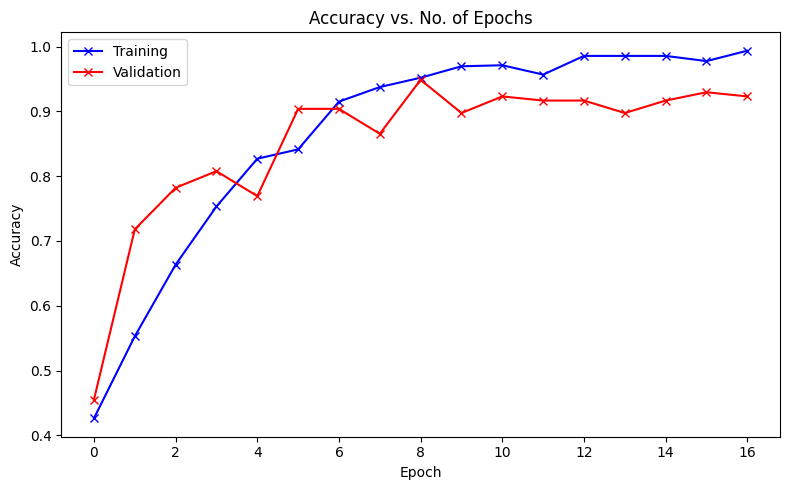

In [ ]:
# ── Accuracy curve ────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.plot(train_acc_hist, '-bx', label='Training')
plt.plot(test_acc_hist,  '-rx', label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs. No. of Epochs')
plt.tight_layout()
plt.show()


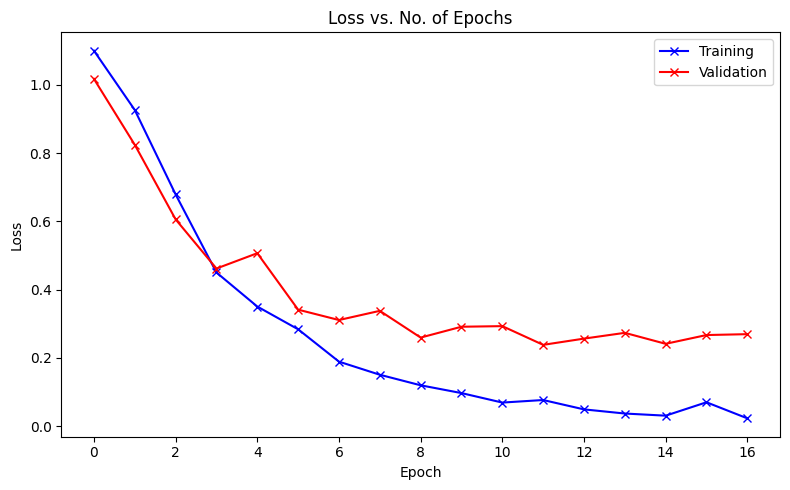

In [ ]:
# ── Loss curve ────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.plot(train_loss_hist, '-bx', label='Training')
plt.plot(test_loss_hist,  '-rx', label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs. No. of Epochs')
plt.tight_layout()
plt.show()


## 10 · Evaluate Predictions on Test Set

Run the saved `best_model.pth` over the full test set, collect all predictions, then produce:
- **Confusion matrix** — shows which classes are confused with each other
- **Classification report** — precision, recall, F1-score per class
- **Prediction grid** — 20 random samples with true vs predicted labels (green = correct · red = wrong)


In [ ]:
all_imgs, all_labels, all_preds = [], [], []

model.eval()
with no_grad():
    for imgs, labels in test_dl:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs      = model(imgs)
        _, preds     = max(outputs, dim=1)
  
        all_imgs.extend(imgs.cpu()) # accumulate images for visualisation
        all_labels.extend(labels.cpu().tolist())
        all_preds.extend(preds.cpu().tolist())


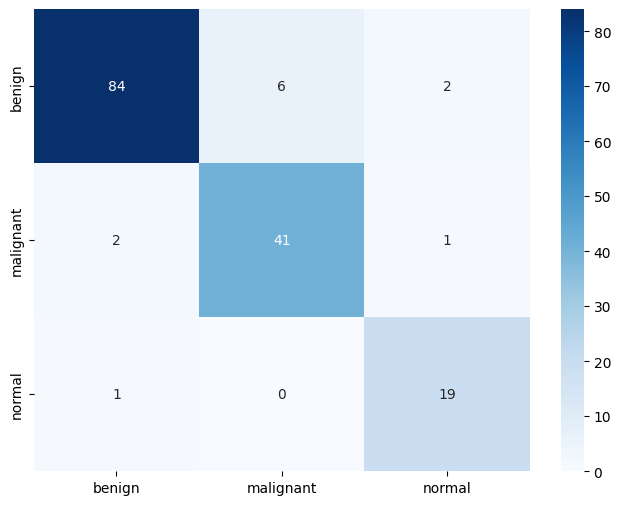

              precision    recall  f1-score   support

      benign       0.97      0.91      0.94        92
   malignant       0.87      0.93      0.90        44
      normal       0.86      0.95      0.90        20

    accuracy                           0.92       156
   macro avg       0.90      0.93      0.91       156
weighted avg       0.93      0.92      0.92       156



In [ ]:
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=base_dataset.classes,
            yticklabels=base_dataset.classes)
plt.show()

print(classification_report(all_labels, all_preds,
                            target_names=base_dataset.classes))

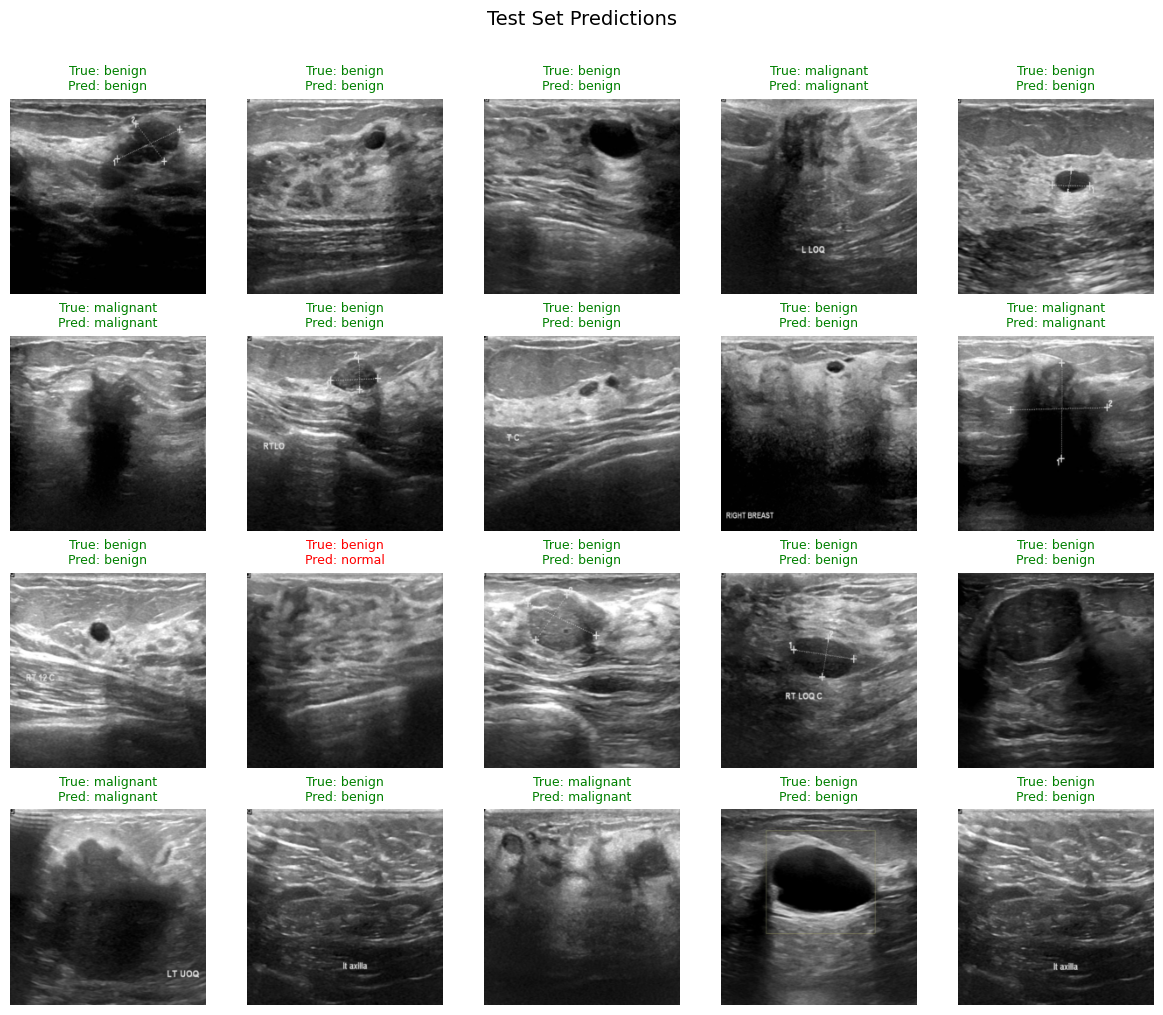

In [ ]:
# ── Display 20 random test predictions in a 4×5 grid ─────────────────────────
_, ax = plt.subplots(4, 5, figsize=(12, 10))
ax = ax.flatten()

for i in range(20):
    idx        = np.random.randint(len(all_labels))
    img        = all_imgs[idx].permute(1, 2, 0).cpu().numpy()  # CHW → HWC
    true_label = base_dataset.classes[all_labels[idx]]
    pred_label = base_dataset.classes[all_preds[idx]]
    correct    = all_preds[idx] == all_labels[idx]

    ax[i].imshow(img)
    ax[i].set_title(
        f"True: {true_label}\nPred: {pred_label}",
        color='green' if correct else 'red',   # green = correct, red = wrong
        fontsize=9
    )
    ax[i].axis("off")

plt.suptitle("Test Set Predictions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
